# Campus Wall Decoration — EfficientNet-B0 Baseline

In [ ]:
# ============================================================
# 1. INSTALL + IMPORTS
# ============================================================

!pip -q install torch torchvision scikit-learn pandas numpy matplotlib seaborn pillow

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from PIL import Image

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [ ]:
# ============================================================
# 2. CONFIG
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

SPLITS_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset"
RAW_IMAGES_FOLDER = "/content/drive/MyDrive/Wall decoration images"
OUTPUT_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results/EfficientNet-B0"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16

# Two-stage fine-tuning schedule
WARMUP_EPOCHS = 8          # backbone frozen, only classifier head trains
WARMUP_LR = 1e-3
FINE_TUNE_EPOCHS = 15       # backbone unfrozen, whole network trains
FINE_TUNE_LR = 5e-6         # much lower than the other backbones -- EfficientNet is sensitive

TASKS = {"wall_type": "multiclass", "indoor": "binary"}


Mounted at /content/drive


## Load splits, resolve image paths, merge train+val



In [ ]:
# ============================================================
# 3. LOAD SPLITS + RESOLVE PATHS
# ============================================================

def load_split(name):
    path = os.path.join(SPLITS_FOLDER, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {path}\nCheck SPLITS_FOLDER in the CONFIG cell.")
    df = pd.read_csv(path, encoding="utf-8-sig")
    keep = ["image_id", "wall_type", "indoor", "description_en", "description_bn", "color_idea", "group_id"]
    return df[[c for c in keep if c in df.columns]].copy()

EXTENSIONS = [".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG", ".webp", ".WEBP"]

def resolve_image_path(image_id):
    for ext in EXTENSIONS:
        candidate = os.path.join(RAW_IMAGES_FOLDER, image_id + ext)
        if os.path.exists(candidate):
            return candidate
    matches = glob.glob(os.path.join(RAW_IMAGES_FOLDER, image_id + ".*"))
    return matches[0] if matches else None

def attach_image_paths(df):
    df = df.copy()
    df["image_path"] = df["image_id"].apply(resolve_image_path)
    missing = df[df["image_path"].isna()]
    if len(missing) > 0:
        print(f"⚠️  {len(missing)} images not found, dropped: {missing['image_id'].tolist()}")
    return df[df["image_path"].notna()].reset_index(drop=True)

train_df = attach_image_paths(load_split("train.csv"))
val_df   = attach_image_paths(load_split("validation.csv"))
test_df  = attach_image_paths(load_split("test.csv"))

for d in (train_df, val_df, test_df):
    d["indoor"] = pd.to_numeric(d["indoor"], errors="coerce").astype(int)

train_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print("Train pool:", len(train_pool_df), "| Test (held out):", len(test_df))

wall_type_encoder = LabelEncoder().fit(train_pool_df["wall_type"])
for d in (train_pool_df, test_df):
    d["wall_type_label"] = wall_type_encoder.transform(d["wall_type"])

WALL_TYPE_CLASSES = list(wall_type_encoder.classes_)
NUM_CLASSES = {"wall_type": len(WALL_TYPE_CLASSES), "indoor": 2}
TARGET_COLUMN = {"wall_type": "wall_type_label", "indoor": "indoor"}
print("wall_type classes:", WALL_TYPE_CLASSES)


Train pool: 264 | Test (held out): 24
wall_type classes: ['backdrop_board', 'brick_wall', 'bulletin_board', 'painted_wall', 'wooden_wall']


In [ ]:
# ============================================================
# 4. DATASET + TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class WallDecorationDataset(Dataset):
    def __init__(self, dataframe, target_column, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            image = img.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row[self.target_column])


## Naive baseline



In [ ]:
# ============================================================
# 5. NAIVE MAJORITY-CLASS BASELINE
# ============================================================

results = []
naive_reference = {}

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    majority_class = train_pool_df[target_column].mode()[0]
    y_true = test_df[target_column].values
    y_pred = np.full_like(y_true, fill_value=majority_class)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    naive_reference[task] = {"accuracy": acc, "macro_f1": f1_macro}
    results.append({"task": task, "method": "naive_majority", "accuracy": acc, "macro_f1": f1_macro})
    print(f"[naive] {task:10s} test acc={acc:.3f} macro_f1={f1_macro:.3f}  <- a collapsed model matches this exactly")


[naive] wall_type  test acc=0.458 macro_f1=0.126  <- a collapsed model matches this exactly
[naive] indoor     test acc=0.792 macro_f1=0.442  <- a collapsed model matches this exactly


## Baseline 1 — EfficientNet-B0 frozen-feature + classical classifiers




In [ ]:
# ============================================================
# 6. EFFICIENTNET-B0 FEATURE EXTRACTOR
# ============================================================

def get_efficientnet_feature_extractor():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    feature_dim = model.classifier[1].in_features   # 1280
    model.classifier = nn.Identity()
    return model.to(DEVICE).eval(), feature_dim


@torch.no_grad()
def extract_features(backbone_model, dataframe, target_column, batch_size=16):
    dataset = WallDecorationDataset(dataframe, target_column, transform=eval_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    all_features, all_labels = [], []
    for images, labels in loader:
        feats = backbone_model(images.to(DEVICE))
        all_features.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_features), np.concatenate(all_labels)


efficientnet_extractor, feature_dim = get_efficientnet_feature_extractor()
print("EfficientNet-B0 pooled feature dim:", feature_dim)

def get_classical_classifiers():
    return {
        "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
        "linear_svm": SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_SEED),
        "knn": KNeighborsClassifier(n_neighbors=5),
    }

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    X_train, y_train = extract_features(efficientnet_extractor, train_pool_df, target_column, BATCH_SIZE)
    X_test,  y_test  = extract_features(efficientnet_extractor, test_df,       target_column, BATCH_SIZE)
    print(f"\n{task}: train features {X_train.shape}, test features {X_test.shape}")

    for clf_name, clf in get_classical_classifiers().items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
        results.append({"task": task, "method": f"frozen_efficientnet_b0_{clf_name}",
                         "accuracy": acc, "macro_f1": f1_macro})
        print(f"  [frozen+{clf_name:10s}] acc={acc:.3f} macro_f1={f1_macro:.3f}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 89.8MB/s]


EfficientNet-B0 pooled feature dim: 1280

wall_type: train features (264, 1280), test features (24, 1280)
  [frozen+logreg    ] acc=0.583 macro_f1=0.480
  [frozen+linear_svm] acc=0.542 macro_f1=0.412
  [frozen+knn       ] acc=0.333 macro_f1=0.264

indoor: train features (264, 1280), test features (24, 1280)
  [frozen+logreg    ] acc=0.917 macro_f1=0.850
  [frozen+linear_svm] acc=0.833 macro_f1=0.619
  [frozen+knn       ] acc=0.792 macro_f1=0.582


## Baseline 2 — EfficientNet-B0 fine-tuned, two-stage with collapse detection



In [ ]:
# ============================================================
# 7. TWO-STAGE FINE-TUNING WITH COLLAPSE DIAGNOSTICS
# ============================================================

def build_efficientnet_classifier(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def compute_class_weights(df, target_column, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=df[target_column].values)
    return torch.tensor(weights, dtype=torch.float32)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    distinct_preds = len(np.unique(all_preds))
    return total_loss / len(loader.dataset), acc, f1_macro, distinct_preds


def finetune_efficientnet_two_stage(task):
    target_column = TARGET_COLUMN[task]
    num_classes = NUM_CLASSES[task]

    train_ds = WallDecorationDataset(train_pool_df, target_column, transform=train_transform)
    test_ds  = WallDecorationDataset(test_df,       target_column, transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = build_efficientnet_classifier(num_classes).to(DEVICE)
    class_weights = compute_class_weights(train_pool_df, target_column, num_classes).to(DEVICE)
    print(f"  class weights for {task}: {class_weights.cpu().numpy().round(3)}")
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # ---- Stage 1: warmup, backbone frozen ----
    for param in model.features.parameters():
        param.requires_grad = False

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=WARMUP_LR
    )

    print(f"\n  --- Stage 1: warmup (backbone frozen), {task} ---")
    for epoch in range(1, WARMUP_EPOCHS + 1):
        train_loss, train_acc, train_f1, distinct_preds = run_epoch(model, train_loader, criterion, optimizer)
        flag = "  ⚠️ COLLAPSING (1 class only)" if distinct_preds == 1 else ""
        print(f"  [warmup {epoch:02d}/{WARMUP_EPOCHS}] loss={train_loss:.3f} acc={train_acc:.3f} "
              f"macro_f1={train_f1:.3f} distinct_preds={distinct_preds}{flag}")

    # ---- Stage 2: full fine-tune, backbone unfrozen, low LR ----
    for param in model.parameters():
        param.requires_grad = True
    optimizer = torch.optim.AdamW(model.parameters(), lr=FINE_TUNE_LR)

    print(f"\n  --- Stage 2: fine-tune (backbone unfrozen, low LR), {task} ---")
    for epoch in range(1, FINE_TUNE_EPOCHS + 1):
        train_loss, train_acc, train_f1, distinct_preds = run_epoch(model, train_loader, criterion, optimizer)
        flag = "  ⚠️ COLLAPSING (1 class only)" if distinct_preds == 1 else ""
        print(f"  [finetune {epoch:02d}/{FINE_TUNE_EPOCHS}] loss={train_loss:.3f} acc={train_acc:.3f} "
              f"macro_f1={train_f1:.3f} distinct_preds={distinct_preds}{flag}")

    test_loss, test_acc, test_f1, test_distinct = run_epoch(model, test_loader, criterion, optimizer=None)
    print(f"\n  -> TEST acc={test_acc:.3f} macro_f1={test_f1:.3f} distinct_preds={test_distinct}")

    if abs(test_acc - naive_reference[task]["accuracy"]) < 0.02 and test_distinct <= 2:
        print(f"  ⚠️  WARNING: test accuracy matches the naive baseline ({naive_reference[task]['accuracy']:.3f}) "
              f"and only {test_distinct} distinct predictions were made -- likely still collapsed. "
              f"Consider lowering FINE_TUNE_LR further or increasing WARMUP_EPOCHS.")

    torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, f"finetuned_efficientnet_b0_{task}.pt"))
    return model, test_acc, test_f1


finetuned_models = {}
for task in TASKS:
    print(f"\n=== Fine-tuning EfficientNet-B0 on {task} (two-stage) ===")
    model, test_acc, test_f1 = finetune_efficientnet_two_stage(task)
    finetuned_models[task] = model
    results.append({"task": task, "method": "finetuned_efficientnet_b0_two_stage",
                     "accuracy": test_acc, "macro_f1": test_f1})



=== Fine-tuning EfficientNet-B0 on wall_type (two-stage) ===
  class weights for wall_type: [1.821 1.354 0.765 0.463 4.062]

  --- Stage 1: warmup (backbone frozen), wall_type ---
  [warmup 01/8] loss=1.583 acc=0.311 macro_f1=0.238 distinct_preds=5
  [warmup 02/8] loss=1.380 acc=0.462 macro_f1=0.439 distinct_preds=5
  [warmup 03/8] loss=1.241 acc=0.534 macro_f1=0.499 distinct_preds=5
  [warmup 04/8] loss=1.128 acc=0.648 macro_f1=0.641 distinct_preds=5
  [warmup 05/8] loss=1.057 acc=0.655 macro_f1=0.646 distinct_preds=5
  [warmup 06/8] loss=0.970 acc=0.727 macro_f1=0.715 distinct_preds=5
  [warmup 07/8] loss=0.915 acc=0.742 macro_f1=0.734 distinct_preds=5
  [warmup 08/8] loss=0.845 acc=0.750 macro_f1=0.747 distinct_preds=5

  --- Stage 2: fine-tune (backbone unfrozen, low LR), wall_type ---
  [finetune 01/15] loss=0.812 acc=0.769 macro_f1=0.755 distinct_preds=5
  [finetune 02/15] loss=0.830 acc=0.758 macro_f1=0.731 distinct_preds=5
  [finetune 03/15] loss=0.782 acc=0.769 macro_f1=0.753

## Results table + confusion matrices

,task,method,accuracy,macro_f1
5,indoor,frozen_efficientnet_b0_logreg,0.916667,0.850000
9,indoor,finetuned_efficientnet_b0_two_stage,0.875000,0.794872
6,indoor,frozen_efficientnet_b0_linear_svm,0.833333,0.619048
7,indoor,frozen_efficientnet_b0_knn,0.791667,0.581882
1,indoor,naive_majority,0.791667,0.441860
8,wall_type,finetuned_efficientnet_b0_two_stage,0.666667,0.685758
2,wall_type,frozen_efficientnet_b0_logreg,0.583333,0.480317
3,wall_type,frozen_efficientnet_b0_linear_svm,0.541667,0.411905
4,wall_type,frozen_efficientnet_b0_knn,0.333333,0.263835
0,wall_type,naive_majority,0.458333,0.125714


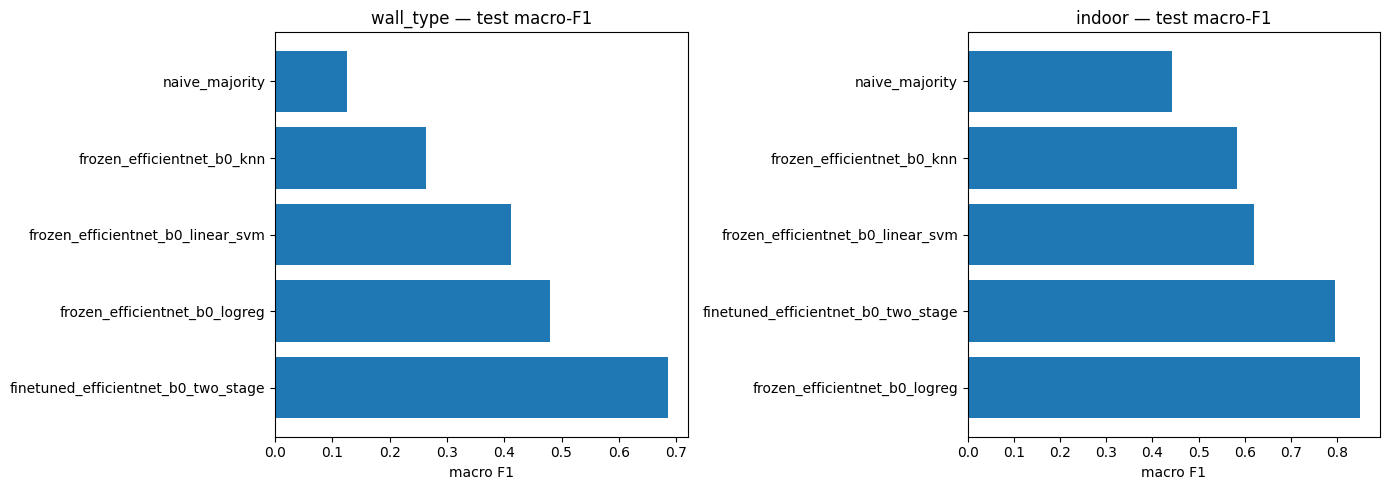

In [ ]:
# ============================================================
# 8. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results).sort_values(["task", "macro_f1"], ascending=[True, False])
results_df.to_csv(os.path.join(OUTPUT_FOLDER, "efficientnet_b0_baseline_results.csv"), index=False)
display(results_df)

fig, axes = plt.subplots(1, len(TASKS), figsize=(7 * len(TASKS), 5))
for ax, task in zip(axes, TASKS):
    sub = results_df[results_df["task"] == task]
    ax.barh(sub["method"], sub["macro_f1"])
    ax.set_title(f"{task} — test macro-F1")
    ax.set_xlabel("macro F1")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "efficientnet_b0_comparison.png"), dpi=150)
plt.show()


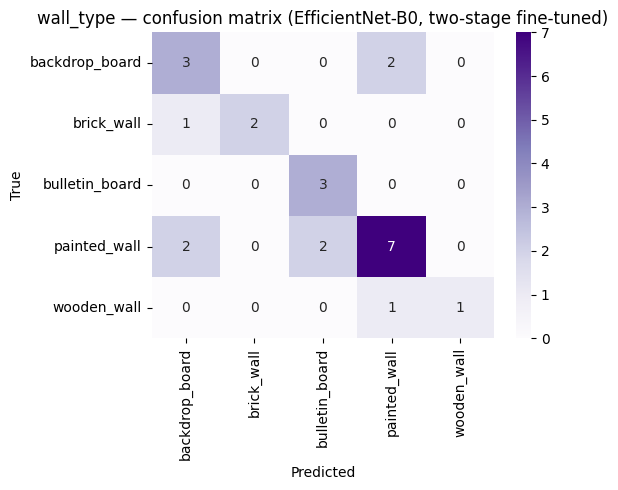


wall_type classification report (EfficientNet-B0, two-stage fine-tuned):
                precision    recall  f1-score   support

backdrop_board       0.50      0.60      0.55         5
    brick_wall       1.00      0.67      0.80         3
bulletin_board       0.60      1.00      0.75         3
  painted_wall       0.70      0.64      0.67        11
   wooden_wall       1.00      0.50      0.67         2

      accuracy                           0.67        24
     macro avg       0.76      0.68      0.69        24
  weighted avg       0.71      0.67      0.67        24



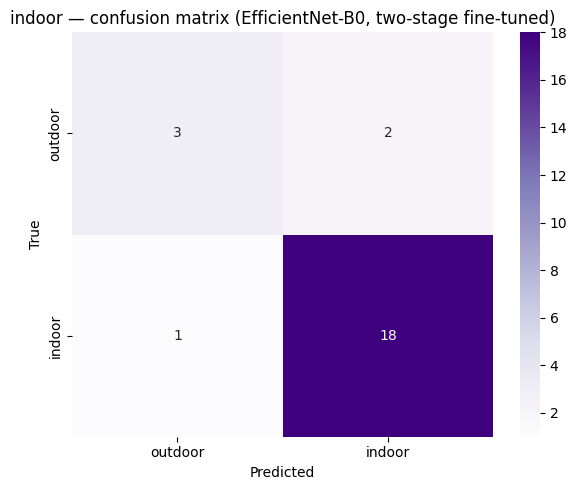


indoor classification report (EfficientNet-B0, two-stage fine-tuned):
              precision    recall  f1-score   support

     outdoor       0.75      0.60      0.67         5
      indoor       0.90      0.95      0.92        19

    accuracy                           0.88        24
   macro avg       0.82      0.77      0.79        24
weighted avg       0.87      0.88      0.87        24



In [ ]:
# ============================================================
# 9. CONFUSION MATRIX FOR THE FINE-TUNED MODEL, PER TASK
# ============================================================

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    model = finetuned_models[task]
    test_ds = WallDecorationDataset(test_df, target_column, transform=eval_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(DEVICE))
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    labels_display = WALL_TYPE_CLASSES if task == "wall_type" else ["outdoor", "indoor"]
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_display, yticklabels=labels_display, cmap="Purples")
    plt.title(f"{task} — confusion matrix (EfficientNet-B0, two-stage fine-tuned)")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, f"efficientnet_b0_confusion_matrix_{task}.png"), dpi=150)
    plt.show()

    print(f"\n{task} classification report (EfficientNet-B0, two-stage fine-tuned):")
    print(classification_report(all_labels, all_preds, target_names=[str(l) for l in labels_display], zero_division=0))


## GroupKFold cross-validation

In [ ]:
# ============================================================
# 10. GROUP K-FOLD CROSS-VALIDATION
# ============================================================

N_FOLDS = 5
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

cv_results = []
for task in TASKS:
    if task == "wall_type":
        full_encoder = LabelEncoder().fit(full_df["wall_type"])
        full_df["wall_type_label"] = full_encoder.transform(full_df["wall_type"])
        target_column = "wall_type_label"
    else:
        target_column = "indoor"

    X_all, y_all = extract_features(efficientnet_extractor, full_df, target_column, BATCH_SIZE)
    groups = full_df["group_id"].values

    n_splits = min(N_FOLDS, pd.Series(groups).nunique())
    gkf = GroupKFold(n_splits=n_splits)
    fold_f1s = []
    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups), start=1):
        clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
        clf.fit(X_all[tr_idx], y_all[tr_idx])
        y_pred = clf.predict(X_all[te_idx])
        f1_macro = f1_score(y_all[te_idx], y_pred, average="macro", zero_division=0)
        fold_f1s.append(f1_macro)
        print(f"[{task}] fold {fold}/{n_splits} macro_f1={f1_macro:.3f}")

    cv_results.append({"task": task, "method": "frozen_efficientnet_b0_logreg_groupkfold",
                        "mean_macro_f1": np.mean(fold_f1s), "std_macro_f1": np.std(fold_f1s)})
    print(f"[{task}] {n_splits}-fold mean macro_f1 = {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}\n")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.to_csv(os.path.join(OUTPUT_FOLDER, "efficientnet_b0_groupkfold_results.csv"), index=False)
display(cv_results_df)


[wall_type] fold 1/5 macro_f1=0.411
[wall_type] fold 2/5 macro_f1=0.516
[wall_type] fold 3/5 macro_f1=0.506
[wall_type] fold 4/5 macro_f1=0.441
[wall_type] fold 5/5 macro_f1=0.490
[wall_type] 5-fold mean macro_f1 = 0.473 ± 0.040

[indoor] fold 1/5 macro_f1=0.808
[indoor] fold 2/5 macro_f1=0.671
[indoor] fold 3/5 macro_f1=0.812
[indoor] fold 4/5 macro_f1=0.851
[indoor] fold 5/5 macro_f1=0.724
[indoor] 5-fold mean macro_f1 = 0.773 ± 0.066



,task,method,mean_macro_f1,std_macro_f1
0,wall_type,frozen_efficientnet_b0_logreg_groupkfold,0.472851,0.040091
1,indoor,frozen_efficientnet_b0_logreg_groupkfold,0.773271,0.065624
